In [1]:
from dotenv import load_dotenv
load_dotenv()

from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

In [12]:
from langgraph.graph import StateGraph, END,  MessagesState
from langchain_core.runnables import RunnableLambda
from langchain_core.messages import HumanMessage
# Define simple echo node
def echo_node(state:  MessagesState):
    message = state.get("messages")[-1].content
    return {"messages": [{"role": "assistant", "content": f"You said: {message}"}]}

# Build the graph
graph_builder = StateGraph( MessagesState)
graph_builder.add_node("echo", RunnableLambda(echo_node))
graph_builder.set_entry_point("echo")
graph_builder.set_finish_point("echo")  # End after one response

graph = graph_builder.compile()


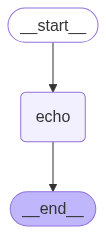

In [13]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
        Image(
            graph.get_graph().draw_mermaid_png(
                draw_method=MermaidDrawMethod.API,
            )
        )
    )

In [14]:
graph.invoke({"messages": [HumanMessage(content="Hi, I am Pankaj, Give me a quote on success")]})["messages"][-1].pretty_print()


================================== Ai Message ==================================

You said: Hi, I am Pankaj, Give me a quote on success
